In [1]:
# Fill missing data in csv files with 0
# # some of the csv are missing data for some datetimes
# # i want to fill the missing data with 0 all data for the same datetime
# import pandas as pd
# import datetime
# from glob import glob
# import numpy

# # got a filename that has all the datetimes with prices
# filename = 'data/SP500.csv'
# #get the list of datetimes in the field timestamp with pandas

# df = pd.read_csv(filename)
# datetimes = df['timestamp'].to_list()

# # get the list of csv files
# files = glob('Data/*.csv')

# # This is a sample of the format of the csv files
# #timestamp,symbol,open,high,low,close,volume,trade_count,vwap
# #2016-06-01 09:30:00-04:00,QSII,12.69,12.74,12.65,12.67,48037.0,208.0,12.706119

# # for each file in the list: 
# # create a new file with the same name +"_filled" , put all the datetimes in the first column with the same format
# # timestamp,symbol,open,high,low,close,volume,trade_count,vwap
# # keep the same order of the columns 
# # if exists data for a datetime, keep the data
# # if there is no data for a datetime, fill the data with 0
# # process the files with pandas

# for file in files:
#     print('Processing file', file)
#     df = pd.read_csv(file)
#     #df['timestamp'] = pd.to_datetime(df['timestamp'])
#     df = df.set_index('timestamp')
#     df.drop_duplicates(keep='first', inplace=True)
#     df = df.reindex(datetimes, fill_value=0)
#     df = df.reset_index()
#     df.to_csv(file.replace('Data/', 'Data/filled_'), index=False)
#     print('File', file, 'processed')

In [2]:
# Fill the 0 data in the .csv files with the last available data
# import pandas as pd
# import datetime
# from glob import glob
# import numpy

# fileList = glob('DataExample/*.csv')
# for file in fileList:
#     print('Processing file', file)
#     df = pd.read_csv(file, index_col='timestamp', parse_dates=True)
#     df.replace(0, pd.NA, inplace=True)
#     df.fillna(method='ffill', inplace=True)
#     df.fillna(0, inplace=True)
#     new_file_name = file.replace('.csv', '_filled.csv')
#     df.reset_index(inplace=True)
#     df.to_csv(new_file_name, index=False)
#     print('File', file, 'processed')

# # Fill the 0 data in the .pk (parquet) files with the last available data
# import pandas as pd
# import datetime
# from glob import glob
# import numpy

# fileList = glob('Data/*.pk')
# for file in fileList:
#     print('Processing file', file)
#     df = pd.read_parquet(file)
#     df.replace(0, pd.NA, inplace=True)
#     df.fillna(method='ffill', inplace=True)
#     df.fillna(0, inplace=True)
#     new_file_name = file.replace('.pk', '_filled.pk')
#     df.to_parquet(new_file_name)
#     print('File', new_file_name, 'processed')

In [3]:
# #Convert to parquet
# from glob import glob
# import pandas as pd


# files = glob('Data/*.csv')

# for file in files:
#     parquet_file_name = file.replace('.csv', '.pk')
#     print(f'Processing file: {file} to {parquet_file_name}')
#     df = pd.read_csv(file, index_col='timestamp', parse_dates=True)
#     # Drop column symbol
#     df.drop(columns='symbol', inplace=True)
#     if parquet_file_name[-3:] == '.pk':
#         df.to_parquet(parquet_file_name, index=True)
#         print("The file was saved as parquet: {parquet_file_name}")

In [4]:
# for the _filled.pk files get the first date with data (close price != 0) and the last date with data (close price != 0)
# put that data in a pandas dataframe with each row the filename and the first and last date 
import pandas as pd
from glob import glob

files = glob('Data/*_filled.pk')

data = []

for file in files:
    df = pd.read_parquet(file)
    first_date = df[df['close'] != 0].index[0]
    last_date = df[df['close'] != 0].index[-1]
    data.append([file, first_date, last_date])

df = pd.DataFrame(data, columns=['filename', 'first_date', 'last_date'])
df
#order the dataframe by the first date
df.sort_values('first_date', inplace=True)
df

,filename,first_date,last_date
0,Data\AAPL_filled.pk,2016-06-01 04:00:00-04:00,2024-02-29 20:00:00-04:00
16,Data\SP500_filled.pk,2016-06-01 04:00:00-04:00,2024-02-29 20:00:00-04:00
10,Data\MSFT_filled.pk,2016-06-01 04:00:00-04:00,2024-02-29 20:00:00-04:00
17,Data\TSLA_filled.pk,2016-06-01 05:30:00-04:00,2024-02-29 20:00:00-04:00
11,Data\NVDA_filled.pk,2016-06-01 05:30:00-04:00,2024-02-29 20:00:00-04:00
12,Data\PFE_filled.pk,2016-06-01 07:45:00-04:00,2024-02-29 20:00:00-04:00
13,Data\PG_filled.pk,2016-06-01 07:45:00-04:00,2024-02-29 20:00:00-04:00
8,Data\JPM_filled.pk,2016-06-01 07:45:00-04:00,2024-02-29 20:00:00-04:00
21,Data\XOM_filled.pk,2016-06-01 07:45:00-04:00,2024-02-29 20:00:00-04:00
7,Data\GOOGL_filled.pk,2016-06-01 07:45:00-04:00,2024-02-29 20:00:00-04:00


In [5]:
# for the .csv files get the first date with data (close price != 0) and the last date with data (close price != 0)
# put that data in a pandas dataframe with each row the filename and the first and last date
# from glob import glob
# import pandas as pd
# files = glob('*.csv')
# data = []
# for file in files:
#     df = pd.read_csv(file)
#     first_date = df[df['close'] != 0].iloc[0]['timestamp']
#     last_date = df[df['close'] != 0].iloc[-1]['timestamp']
#     data.append([file, first_date, last_date]) 

# df = pd.DataFrame(data, columns=['filename', 'first_date', 'last_date'])
# df
# #order the dataframe by the first date
# df.sort_values('last_date', inplace=True)
# df

In [6]:
import pandas as pd
from datetime import datetime

# Danh sách các cổ phiếu trong Dow Jones 30
tickers = ['AAPL','ABCB','CSCO','DAL','EAST','ESPR','F',
           'GOOGL','JPM','META','MSFT','NVDA','PFE','PG','PSX',
           'SGLY','SP500','TSLA','UNH','USA','WMT','XOM']

# ticker of benchmark
benchmark = 'SP500'

# Get the data from the CSV files
stock_data = {}
for ticker in tickers:
    df = pd.read_parquet(f'Data/{ticker}_filled.pk')
    #pass the columns to capitalize
    df.columns = df.columns.str.capitalize()
    stock_data[ticker] = df


# Establish the time range for the data
#trainInit = datetime.fromisoformat('2016-06-01 00:00:01-04:00')
trainInit = datetime.fromisoformat('2018-01-01 00:00:01-04:00')
trainEnd = datetime.fromisoformat('2024-01-01 00:00:01-04:00')

# split the data into training
training_data_time_range = (trainInit, trainEnd)

# split the data into training, validation and test sets
training_data = {}

for ticker, df in stock_data.items():
    training_data[ticker] = df.loc[training_data_time_range[0]:training_data_time_range[1]]

# print shape of training, validation and test data
ticker = 'AAPL'
print(f'Training data shape for {ticker}: {training_data[ticker].shape}')

# Display the first 5 rows of the data
training_data['AAPL'].head()

Training data shape for AAPL: (94264, 7)


,Open,High,Low,Close,Volume,Trade_count,Vwap
timestamp,,,,,,,
2018-01-02 05:00:00-04:00,169.10,169.11,169.1,169.11,2018.0,24.0,169.106932
2018-01-02 05:15:00-04:00,169.10,169.11,169.1,169.11,2018.0,24.0,169.106932
2018-01-02 05:30:00-04:00,169.20,169.20,169.2,169.20,1000.0,3.0,169.200000
2018-01-02 05:45:00-04:00,169.16,169.18,169.1,169.18,5428.0,13.0,169.105029
2018-01-02 06:00:00-04:00,169.25,169.29,169.0,169.00,3786.0,32.0,169.108297


In [7]:
import pandas as pd
import numpy as np

def add_technical_indicators(df):
    # calculate RSI 14 
    delta = df['Close'].diff()
    up = delta.where(delta > 0, 0)
    down = -delta.where(delta < 0, 0)
    rs = up.rolling(window=14).mean() / down.rolling(window=14).mean()
    df['RSI'] = 100 - (100 / (1 + rs))

    # EMA 12 / 26  en MACD
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    # RSI 14
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # CCI 20
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    sma_tp = tp.rolling(window=20).mean()
    mean_dev = tp.rolling(window=20).apply(lambda x: np.mean(np.abs(x - x.mean())))
    df['CCI'] = (tp - sma_tp) / (0.015 * mean_dev)
    
    # ADX 14
    high_diff = df['High'].diff()
    low_diff = df['Low'].diff()
    df['+DM'] = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0)
    df['-DM'] = np.where((low_diff > high_diff) & (low_diff > 0), low_diff, 0)
    tr = pd.concat([df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift(1)), np.abs(df['Low'] - df['Close'].shift(1))], axis=1).max(axis=1)
    atr = tr.ewm(span=14, adjust=False).mean()
    df['+DI'] = 100 * (df['+DM'].ewm(span=14, adjust=False).mean() / atr)
    df['-DI'] = 100 * (df['-DM'].ewm(span=14, adjust=False).mean() / atr)
    dx = 100 * np.abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])
    df['ADX'] = dx.ewm(span=14, adjust=False).mean()

    # drop NaN values
    # df.dropna(inplace=True)
    # Fill NaN values with -1
    df.fillna(-1, inplace=True)

    # keep Open, High, Low, Close, Volume, MACD, Signal, RSI, CCI, ADX
    df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MACD', 'Signal', 'RSI', 'CCI', 'ADX']]

    return df

In [8]:
# add technical indicators to the training data for each stock
for ticker, df in training_data.items():
    training_data[ticker] = add_technical_indicators(df)

# Create benchmark data
benchmark_training_data = training_data[benchmark]

# print the first 5 rows of the data
print('Shape of training data for AAPL:', training_data['AAPL'].shape)

# print the first 5 rows of the benchmark data
print('Shape of training benchmark data:', benchmark_training_data.shape)

C:\Users\tcorn\AppData\Local\Temp\ipykernel_25820\2322656593.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RSI'] = 100 - (100 / (1 + rs))
C:\Users\tcorn\AppData\Local\Temp\ipykernel_25820\2322656593.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
C:\Users\tcorn\AppData\Local\Temp\ipykernel_25820\2322656593.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

Shape of training data for AAPL: (94264, 10)
Shape of training benchmark data: (94264, 10)


C:\Users\tcorn\AppData\Local\Temp\ipykernel_25820\2322656593.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CCI'] = (tp - sma_tp) / (0.015 * mean_dev)
C:\Users\tcorn\AppData\Local\Temp\ipykernel_25820\2322656593.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['+DM'] = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0)
C:\Users\tcorn\AppData\Local\Temp\ipykernel_25820\2322656593.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


In [9]:
def pearsonccs(samples):
    C = np.cov(samples)
    diag = np.diag(C)
    N = np.sqrt(np.outer(diag, diag))
    N[N == 0] = 1
    return C / N

In [10]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class StockTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    
    def __init__(self, stock_data , benchmark_data, return_memory_size=5):
        super(StockTradingEnv, self).__init__()

        # Define the benchmark
        self.benchmark_data = benchmark_data
        
        # Initialize of memory
        self.return_memory_size = return_memory_size
        self.last_return_memory_benchmark = []
        self.last_return_memory_portfolio = []
        self.benchmark_portfolio_correlation = 0

        self.portfolio_return = []

        self.benchmark_portfolio_total_correlation = 0

        # Remove any empty DataFrames from the stock data
        self.stock_data = {ticker: df for ticker, df in stock_data.items() if not df.empty}     
        self.tickers = list(self.stock_data.keys())
        print(f"Stock data has been loaded for {len(self.tickers)} stocks.")
        print(f"The tickers are: {self.tickers}")
        
        if not self.tickers:
            raise ValueError("All provided stock data is empty")
        
        # Calculate the size of one stock's data
        sample_df = next(iter(self.stock_data.values()))
        self.n_features = len(sample_df.columns)
        
        # Define action and observation space
        self.action_space = spaces.Box(low=-1, high=1, shape=(len(self.tickers),), dtype=np.float32)
        
        # Observation space: price data for each stock + balance + net worth + shares held + max net worth + current step
        self.obs_shape = self.n_features * len(self.tickers) + 2 + len(self.tickers) + 2
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_shape,), dtype=np.float32)
        
        # Initialize account balance
        self.initial_balance = 100000
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.shares_held = {ticker: 0 for ticker in self.tickers}
        self.total_shares_sold = {ticker: 0 for ticker in self.tickers}
        self.total_sales_value = {ticker: 0 for ticker in self.tickers}
        
        # Set the current step and the episode step
        self.current_step = 0
        self.episode_step = 0
        self.current_date = self.benchmark_data.index[self.current_step].date().strftime('%Y-%m-%d')
        
        # Initialize the current date for separate days
        self.is_last_tick_of_day = False

    def hard_reset(self):
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.shares_held = {ticker: 0 for ticker in self.tickers}
        self.total_shares_sold = {ticker: 0 for ticker in self.tickers}
        self.total_sales_value = {ticker: 0 for ticker in self.tickers}
        self.episode_step = 0
        
        self.is_last_tick_of_day = False
        self.last_return_memory_benchmark = []
        self.last_return_memory_portfolio = []

        self.portfolio_return = []

        self.benchmark_portfolio_correlation = 0
        self.benchmark_portfolio_total_correlation = 0
        
        #Especifico del hard reset
        self.current_step = 0
        self.current_date = self.benchmark_data.index[self.current_step].date().strftime('%Y-%m-%d')

        return self._next_observation(), {}

        
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.shares_held = {ticker: 0 for ticker in self.tickers}
        self.total_shares_sold = {ticker: 0 for ticker in self.tickers}
        self.total_sales_value = {ticker: 0 for ticker in self.tickers}
        self.episode_step = 0
        self.is_last_tick_of_day = False
        self.last_return_memory_benchmark = []
        self.last_return_memory_portfolio = []

        self.portfolio_return = []

        self.benchmark_portfolio_correlation = 0
        self.benchmark_portfolio_total_correlation = 0

        return self._next_observation(), {}
    
    def _next_observation(self):
        frame = np.zeros(self.obs_shape)
        
        idx = 0
        for ticker in self.tickers:
            df = self.stock_data[ticker]
            if self.current_step < len(df):
                frame[idx:idx+self.n_features] = df.iloc[self.current_step].values
            elif len(df) > 0:
                frame[idx:idx+self.n_features] = df.iloc[-1].values
            idx += self.n_features
        
        frame[-4-len(self.tickers)] = self.balance
        frame[-3-len(self.tickers):-3] = [self.shares_held[ticker] for ticker in self.tickers]
        frame[-3] = self.net_worth
        frame[-2] = self.max_net_worth
        frame[-1] = self.episode_step
        
        return frame
    
    def step(self, actions):
        self.current_step += 1
        self.episode_step += 1
        self.current_date = self.benchmark_data.index[self.current_step].date().strftime('%Y-%m-%d')

        if self.is_last_tick_of_day:
            return self._next_observation(), 0, True, False, {}
        
        current_prices = {}
        for i, ticker in enumerate(self.tickers):
            current_prices[ticker] = self.stock_data[ticker].iloc[self.current_step]['Close']
            action = actions[i]
            
            # Buy or sell the stocks just if the price is different from 0
            if current_prices[ticker] != 0.0:
                if action > 0:  # Buy
                    shares_to_buy = int(self.balance * action / current_prices[ticker])
                    cost = shares_to_buy * current_prices[ticker]
                    self.balance -= cost
                    self.shares_held[ticker] += shares_to_buy
                elif action < 0:  # Sell
                    shares_to_sell = int(self.shares_held[ticker] * abs(action))
                    sale = shares_to_sell * current_prices[ticker]
                    self.balance += sale
                    self.shares_held[ticker] -= shares_to_sell
                    self.total_shares_sold[ticker] += shares_to_sell
                    self.total_sales_value[ticker] += sale
            else:
                print(f"Price for {ticker} in {self.current_date} is 0.0")
        

        self.last_net_worth = self.net_worth
        self.net_worth = self.balance + sum(self.shares_held[ticker] * current_prices[ticker] for ticker in self.tickers)
        self.max_net_worth = max(self.net_worth, self.max_net_worth)
        
        reward = self.net_worth - self.initial_balance
        done = (self.net_worth <= 0 or self.is_last_tick_of_day)

        # Calculate the return of the benchmark (just from second step)
        if self.episode_step > 0:
            benchmark_return = self.benchmark_data.iloc[self.current_step]['Close'] / self.benchmark_data.iloc[self.current_step - 1]['Close'] - 1
            #Add the return to the benchmark to the memory but if the memory is full, remove the oldest return
            if len(self.last_return_memory_benchmark) >= self.return_memory_size:
                self.last_return_memory_benchmark.pop(0)
            self.last_return_memory_benchmark.append(benchmark_return)
            

            # Calculate the return of the portfolio
            portfolio_return = self.net_worth / self.last_net_worth - 1
            self.portfolio_return.append(portfolio_return)
            # Add the return to the portfolio to the memory but if the memory is full, remove the oldest return
            if len(self.last_return_memory_portfolio) >= self.return_memory_size:
                self.last_return_memory_portfolio.pop(0)
            self.last_return_memory_portfolio.append(portfolio_return)

        
        # Calculate the pearson correlation between the benchmark memory and the portfolio memory just if the memory is full
        if len(self.last_return_memory_benchmark) == self.return_memory_size and \
           len(self.last_return_memory_portfolio) == self.return_memory_size:
            self.benchmark_portfolio_correlation = pearsonccs([self.last_return_memory_benchmark, self.last_return_memory_portfolio])[0][1]   
        else:
            self.benchmark_portfolio_correlation = 0
        
        # Update the is_last_tick_of_day variable
        self.is_last_tick_of_day = self.benchmark_data.index[self.current_step].date().strftime('%Y-%m-%d') \
            != self.benchmark_data.index[self.current_step + 1].date().strftime('%Y-%m-%d')

        obs = self._next_observation()
        return obs, reward, done, False, {}
    
    def render(self, mode='human'):
        profit = self.net_worth - self.initial_balance
        print(f'Step: {self.current_step}')
        print(f'Benchmark-Portfolio Correlation: {self.benchmark_portfolio_correlation:.2f}')
        print(f'Balance: {self.balance:.2f}')
        for ticker in self.tickers:
            print(f'{ticker} Shares held: {self.shares_held[ticker]}')
        print(f'Net worth: {self.net_worth:.2f}')
        print(f'Profit: {profit:.2f}')

    def close(self):
        pass

In [11]:
from stable_baselines3.common.utils import get_device

In [12]:
get_device(device='cuda')

device(type='cuda')

In [13]:
from stable_baselines3 import PPO, A2C, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv

# # Define Ensemble Agent
# class EnsembleAgent:
#     def __init__(self, ppo_model, a2c_model, ddpg_model):
#         self.ppo_model = ppo_model
#         self.a2c_model = a2c_model
#         self.ddpg_model = ddpg_model
    
#     def predict(self, obs):
#         ppo_action, _ = self.ppo_model.predict(obs)
#         a2c_action, _ = self.a2c_model.predict(obs)
#         ddpg_action, _ = self.ddpg_model.predict(obs)
        
#         # Average the actions
#         ensemble_action = np.mean([ppo_action, a2c_action, ddpg_action], axis=0)
#         return ensemble_action
    
# Define PPO Agent
class PPOAgent:
    def __init__(self, env, n_steps):
        self.model_type = "SB3"
        self.model = PPO("MlpPolicy", env, n_steps=n_steps ,verbose=1, device='cuda')
    
    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action
    
# Define A2C Agent
class A2CAgent:
    def __init__(self, env, n_steps):
        self.model_type = "SB3"
        self.model = A2C("MlpPolicy", env, n_steps=n_steps, verbose=1, device='cuda')
    
    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action
    
# Define DDPG Agent
class DDPGAgent:
    def __init__(self, env):
        self.model_type = "SB3"
        self.model = DDPG("MlpPolicy", env, verbose=1, device='cuda')
    
    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action
    
# Define Random Agent
class RandomAgent:
    def __init__(self, env):
        self.model_type = "Random"
        self.env = env
        self.tickers_len = len(env.get_attr('tickers')[0])
    
    def predict(self, obs):
        return np.random.uniform(-1, 1, self.tickers_len).reshape(1, self.tickers_len)

# Define SP500 Agent
class SP500Agent:
    def __init__(self, env):
        self.model_type = "SP500"
        self.env = env
        self.tickers = env.get_attr('tickers')[0]
        self.tickers_len = len(self.tickers)
        self.SP500idx = self.tickers.index('SP500')

        
        print("Tickers en init SP500Agent")
        print(self.env.get_attr('tickers')[0])
    
    def predict(self, obs):
        current_step = int(self.env.get_attr('episode_step')[0])
        # create a empty array of zeros
        actions = np.zeros(self.tickers_len).reshape(1, self.tickers_len)
        if current_step == 0:
            # Buy SP500
            actions[0, self.SP500idx] = 1
        return actions

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to create the environment and train the agents
def create_env_and_train_agents(data, benchmark_data, n_steps):
    # Create the environment using DummyVecEnv with training data
    env = DummyVecEnv([lambda: StockTradingEnv(data, benchmark_data, return_memory_size=5)])

    # Train PPO Agent
    ppo_agent = PPOAgent(env, n_steps=n_steps)

    # Train A2C Agent
    a2c_agent = A2CAgent(env, n_steps=n_steps)

    # Train DDPG Agent
    ddpg_agent = DDPGAgent(env)

    # Declaring Random Agent
    random_agent = RandomAgent(env)

    # Declaring SP500 Agent
    sp500_agent = SP500Agent(env)

    # Train the ensemble agent
    #ensemble_agent = EnsembleAgent(ppo_agent.model, a2c_agent.model, ddpg_agent.model)
    
    return env, ppo_agent, a2c_agent, ddpg_agent, random_agent, sp500_agent #, ensemble_agent

In [15]:
##Hacer Modificación para Visualizar Episodios
def train_test_SB3_agent(env, agent, n_total_episodes=100, testing_points=10):
    """
    Test a single agent and track performance metrics, with an option to visualize the results.
    #TODO Corregir documentacion
    Parameters:
    - env: The trading environment.
    - agent: The agent to be tested.
    - stock_data: Data for the stocks in the environment.
    - n_tests: Number of tests to run (default: 1000).
    - visualize: Boolean flag to enable or disable visualization (default: False).

    Returns:
    - A dictionary containing steps, balances, net worths, and shares held.
    """
    # Initialize metrics tracking
    metrics = {
        'dates': [],
        'net_worths_delta': [],
        'shares_held': [],
        'pearson_correlations': [],
        'rewards': [],
        'portfolio_returns': [],
        'stds': [],
        'sharpe_ratios': []
    }

    # Reset the environment before starting the tests
    obs = np.array([env.env_method('hard_reset')[0][0].tolist()]) # env.reset()#

    # Get the training partition number of episodes
    partition = int(n_total_episodes / testing_points) - 1
    EPISODE_STEP_CONST = 64
    
    # Set the episode loop
    for i_tpoint in range(testing_points):
        # First Evaluate the agents
        print(f"--------------Testing Point {i_tpoint+1} of {testing_points}-----------------------------------")
        # Set the initial episode values
        done = False
        cum_reward = 0
        local_pearson_correlations = []
        local_portfolio_returns = []
        metrics['dates'].append(env.get_attr('current_date')[0])
        
    
        initial_testing_net_worth = env.get_attr('net_worth')[0]

        #TODO Take off Later
        print("Fecha Inicial: ", env.get_attr('current_date')[0])
        print("Current Step Inicial: ", env.get_attr('current_step')[0])

        net_worth_list = []
        episode_step_final_testing_list = []
        last_testing_shares_held_list = []
        
        # Run the testing episode
        while not done:
            action = agent.predict(obs)
            obs, reward, done, _info = env.step(action)
            local_pearson_correlations.append(env.get_attr('benchmark_portfolio_correlation')[0])
            episode_step_final_testing_list.append(env.get_attr('episode_step')[0])
            net_worth_list.append(env.get_attr('net_worth')[0])
            last_testing_shares_held_list.append(env.get_attr('shares_held')[0])
            local_portfolio_returns.append(env.get_attr('portfolio_return')[0])
            cum_reward += reward
            
            
        print("Fecha Final: ", env.get_attr('current_date')[0])
        print("Current Step Final: ", env.get_attr('current_step')[0])
        print("Episode Step Final: ", episode_step_final_testing_list[-2])
        print("Reward: ", cum_reward)

        net_worth_delta = net_worth_list[-2] - initial_testing_net_worth
        # Append metrics
        metrics['net_worths_delta'].append(net_worth_delta)
        metrics['pearson_correlations'].append(np.mean(local_pearson_correlations))
        metrics['rewards'].append(cum_reward[0])
        metrics['portfolio_returns'].append(np.mean(local_portfolio_returns[0][1:]))
        metrics['stds'].append(np.std(local_portfolio_returns[0][1:]))
        metrics['sharpe_ratios'].append((net_worth_delta / initial_testing_net_worth) / np.std(local_portfolio_returns[0][1:]))

        # Update shares held for each ticker
        # Hacer caso especial para SB3
        if agent.model_type == "SB3":
            metrics['shares_held'].append(last_testing_shares_held_list[-2])
        else:
            metrics['shares_held'].append(last_testing_shares_held_list[-1])


        #After train the agent by partition of episodes
        print("Fecha antes train: ", env.get_attr('current_date')[0])
        print("Current Step antes train: ", env.get_attr('current_step')[0])
        if agent.model_type == "SB3":
            agent.model.learn(EPISODE_STEP_CONST*partition)
        else:
            # El agente Random y SP500 no se entrenan
            for i in range(EPISODE_STEP_CONST*partition):
                action = agent.predict(obs)
                obs, _reward, done, _info = env.step(action)
        print("Fecha despues train: ", env.get_attr('current_date')[0])

        obs = env.reset()

    return metrics

In [16]:
def getResumeMetricsSB3(env, agents, n_total_episodes=50, testing_points=5):
    metrics_resume = {}
    for agent_name, agent in agents.items():
        print(f"Testing {agent_name}...")
        metrics_resume[agent_name] = train_test_SB3_agent(env, agent, n_total_episodes, testing_points)
        print(f"Done testing {agent_name}!")
    
    print('-'*50)
    print('All agents tested!')
    print('-'*50)

    return metrics_resume

In [17]:
EPISODE_STEP_CONST = 64
N_TOTAL_EPISODES = 900
TESTING_POINTS = 50

partition = int(N_TOTAL_EPISODES / TESTING_POINTS) - 1
n_steps = EPISODE_STEP_CONST*partition

# 1. Create the environment and train the agents
env, ppo_agent, a2c_agent, ddpg_agent, random_agent , sp500_agent = create_env_and_train_agents(training_data, benchmark_training_data, n_steps=n_steps)

# 2. Test & visualize the agents
agents = {
    'PPO Agent': ppo_agent,
    'A2C Agent': a2c_agent,
    'DDPG Agent': ddpg_agent,
    'Random Agent': random_agent,
    'SP500 Agent': sp500_agent
}
metrics_resume = getResumeMetricsSB3(env, agents, n_total_episodes=N_TOTAL_EPISODES, testing_points=TESTING_POINTS)

Stock data has been loaded for 22 stocks.
The tickers are: ['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Using cuda device
Using cuda device
Using cuda device
Tickers en init SP500Agent
['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Testing PPO Agent...
--------------Testing Point 1 of 50-----------------------------------
Fecha Inicial:  2018-01-02
Current Step Inicial:  0
Fecha Final:  2018-01-03
Current Step Final:  64
Episode Step Final:  63
Reward:  [39022.45]
Fecha antes train:  2018-01-03
Current Step antes train:  64
-----------------------------
| time/              |      |
|    fps             | 69   |
|    iterations      | 1    |
|    time_elapsed    | 15   |
|    total_timesteps | 1088 |
-----------------------------
Fecha despues train:

In [ ]:
# Save the dictionary metrics_resume to json file
import json

with open('metrics_resume.json', 'w') as f:
    json.dump(metrics_resume, f)


In [18]:
# Check Fechas de los episodios para cada agente
PPOAgentDates = metrics_resume['PPO Agent']['dates']
A2CAgentDates = metrics_resume['A2C Agent']['dates']
DDPGAgentDates = metrics_resume['DDPG Agent']['dates']
RandomAgentDates = metrics_resume['Random Agent']['dates']
SP500AgentDates = metrics_resume['SP500 Agent']['dates']
dates_df = pd.DataFrame({
    'PPO Agent': PPOAgentDates,
    'A2C Agent': A2CAgentDates,
    'DDPG Agent': DDPGAgentDates,
    'Random Agent': RandomAgentDates,
    'SP500 Agent': SP500AgentDates
})
dates_df

,PPO Agent,A2C Agent,DDPG Agent,Random Agent,SP500 Agent
0,2018-01-02,2018-01-02,2018-01-02,2018-01-02,2018-01-02
1,2018-01-29,2018-01-29,2018-01-29,2018-01-29,2018-01-29
2,2018-02-23,2018-02-23,2018-02-23,2018-02-23,2018-02-23
3,2018-03-21,2018-03-21,2018-03-21,2018-03-21,2018-03-21
4,2018-04-17,2018-04-17,2018-04-17,2018-04-17,2018-04-17
5,2018-05-11,2018-05-11,2018-05-11,2018-05-11,2018-05-11
6,2018-06-07,2018-06-07,2018-06-07,2018-06-07,2018-06-07
7,2018-07-03,2018-07-03,2018-07-03,2018-07-03,2018-07-03
8,2018-07-30,2018-07-30,2018-07-30,2018-07-30,2018-07-30
9,2018-08-23,2018-08-23,2018-08-23,2018-08-23,2018-08-23


In [19]:
# Visualizar las métricas de los agentes usando dates como x-axis (con las etiquetas en diagonal) y la metrica como y-axis
def plot_metrics(metrics):
    # Get a list of all the posible dates from the metrics
    #available_dates 
    #for agent_name, agent_metrics in metrics.items():

    ## Plot Rewards
    plt.figure(figsize=(15, 5))
    for agent_name, agent_metrics in metrics.items():
        plt.plot(agent_metrics['dates'], agent_metrics['rewards'], label=agent_name)
    plt.xticks(rotation=45)
    plt.title('Rewards Per Episode')
    plt.xlabel('Date')
    plt.ylabel('Rewards')
    plt.legend()
    plt.show()

    ## Plot Net Worths Delta
    plt.figure(figsize=(15, 5))
    for agent_name, agent_metrics in metrics.items():
        plt.plot(agent_metrics['dates'], agent_metrics['net_worths_delta'], label=agent_name)
    plt.xticks(rotation=45)
    plt.title('Net Worths Delta Per Episode')
    plt.xlabel('Date')
    plt.ylabel('Net Worths Delta')
    plt.legend()
    plt.show()

    ## Plot Pearson Correlations
    plt.figure(figsize=(15, 5))
    for agent_name, agent_metrics in metrics.items():
        plt.plot(agent_metrics['dates'], agent_metrics['pearson_correlations'], label=agent_name)
    plt.xticks(rotation=45)
    plt.title('Pearson Correlations Per Episode')
    plt.xlabel('Date')
    plt.ylabel('Pearson Correlations')
    plt.legend()
    plt.show()

    ## Plot Portfolio Returns
    plt.figure(figsize=(15, 5))
    for agent_name, agent_metrics in metrics.items():
        plt.plot(agent_metrics['dates'], agent_metrics['portfolio_returns'], label=agent_name)
    plt.xticks(rotation=45)
    plt.title('Portfolio Returns Per Episode')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Returns')
    plt.legend()
    plt.show()

    ## Plot Sharpe Ratios
    plt.figure(figsize=(15, 5))
    for agent_name, agent_metrics in metrics.items():
        plt.plot(agent_metrics['dates'], agent_metrics['sharpe_ratios'], label=agent_name)
    plt.xticks(rotation=45)
    plt.title('Sharpe Ratios Per Episode')
    plt.xlabel('Date')
    plt.ylabel('Sharpe Ratios')
    plt.legend()
    plt.show()

    

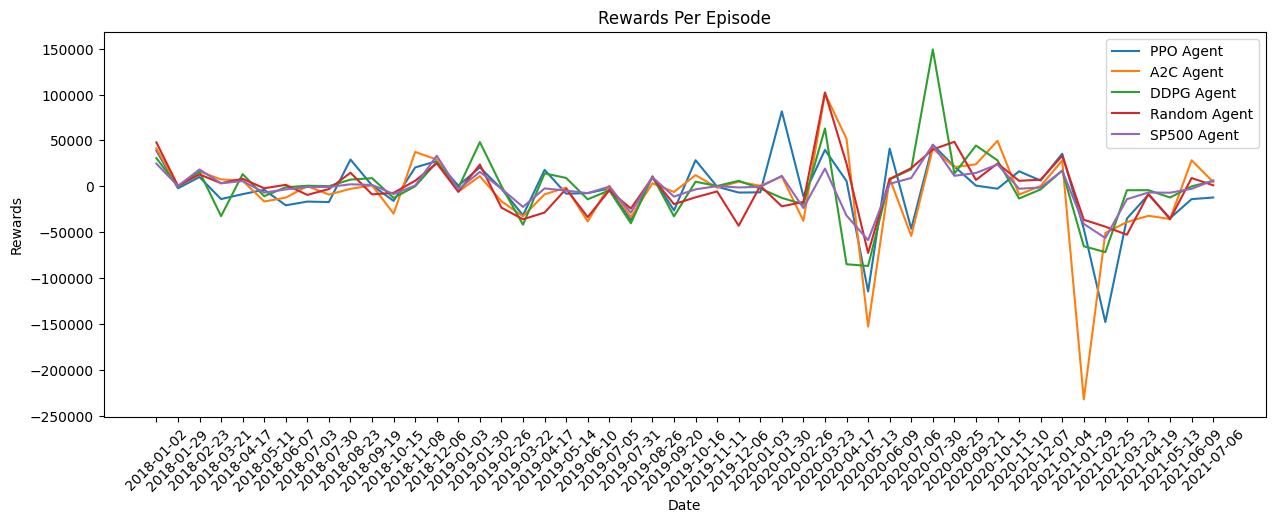

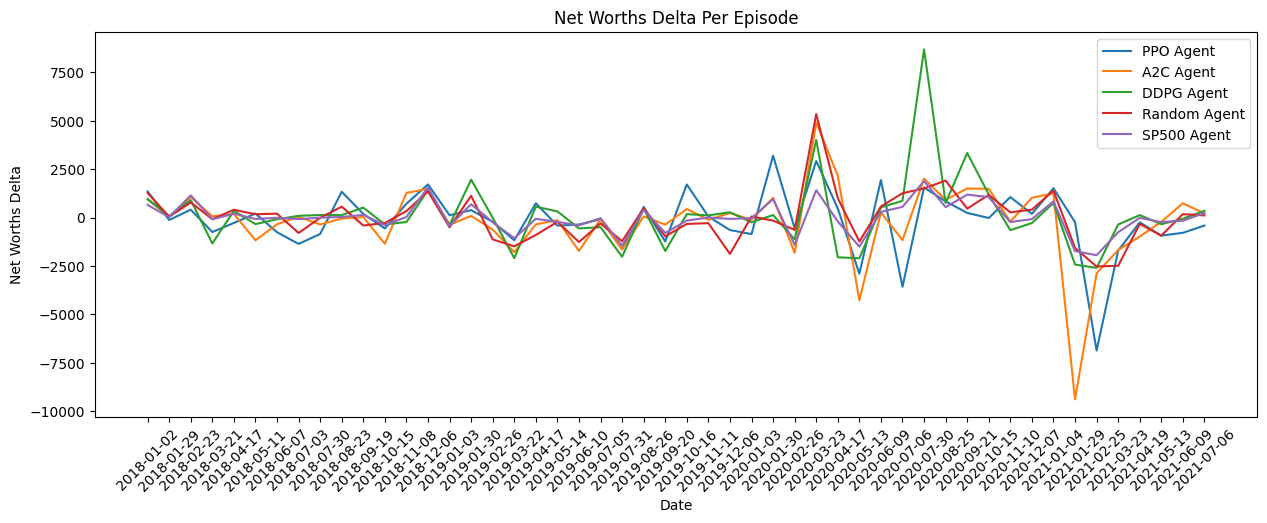

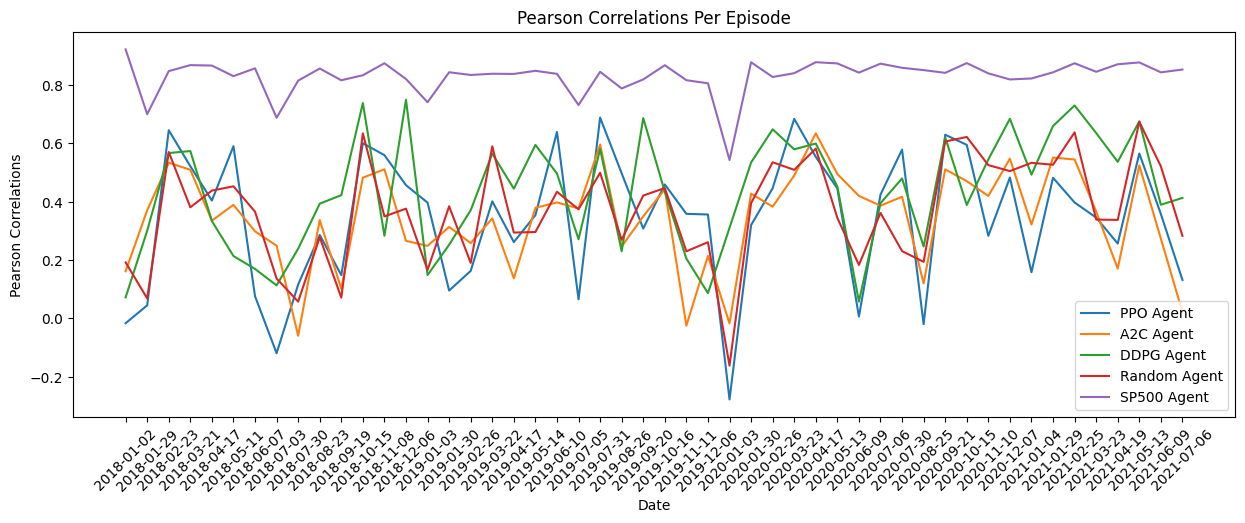

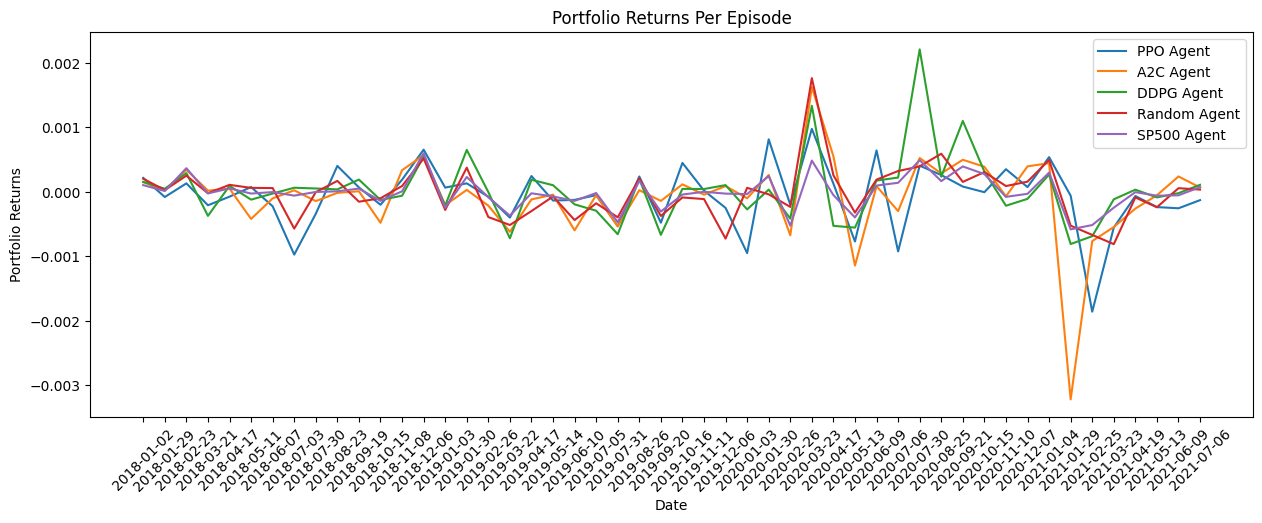

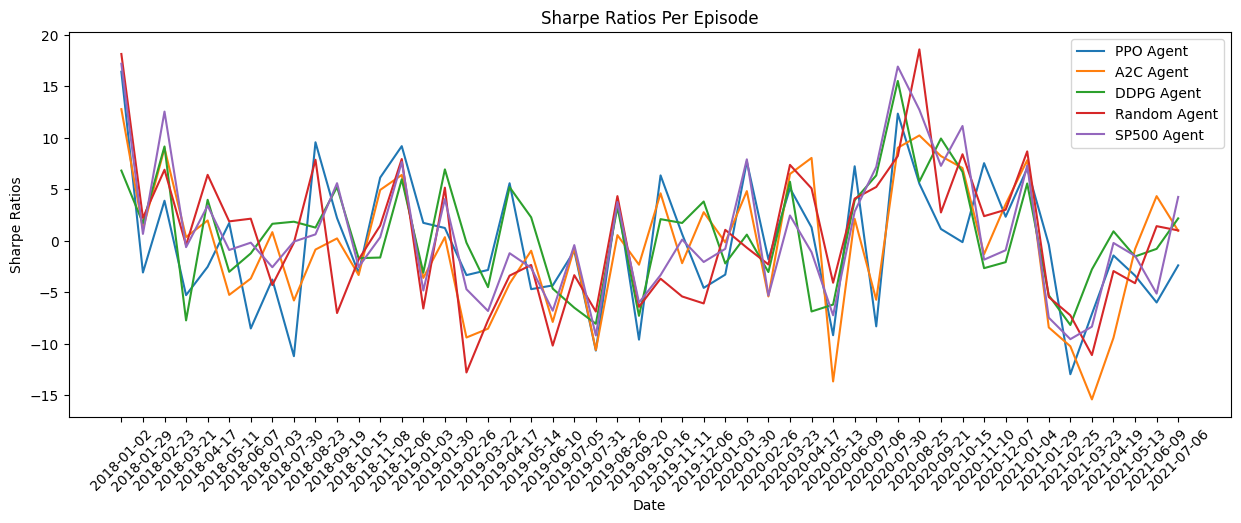

In [20]:
plot_metrics(metrics_resume)

In [21]:
def SharesHeldPlot(agents_metrics):
    agents_to_plot = list(agents_metrics.keys())
    for i in range(len(agents_to_plot)):
        #Create the dataframe for shares_held where each row is a ticker , each column is a step and the value is the shares held
        df = pd.DataFrame.from_dict(metrics_resume[agents_to_plot[i]]['shares_held']).T
        #Filter the rows where the sum of the shares held is greater than 0
        df = df.loc[(df.sum(axis=1) > 0)]
        #Now plot a line char where each line is a ticker and the x axis is the step
        df.T.plot(figsize=(12, 6))
        plt.title(f'Shares Held Over Time for {agents_to_plot[i]}')
        plt.xlabel('Episodes')
        plt.ylabel('Shares Held')
        plt.show()

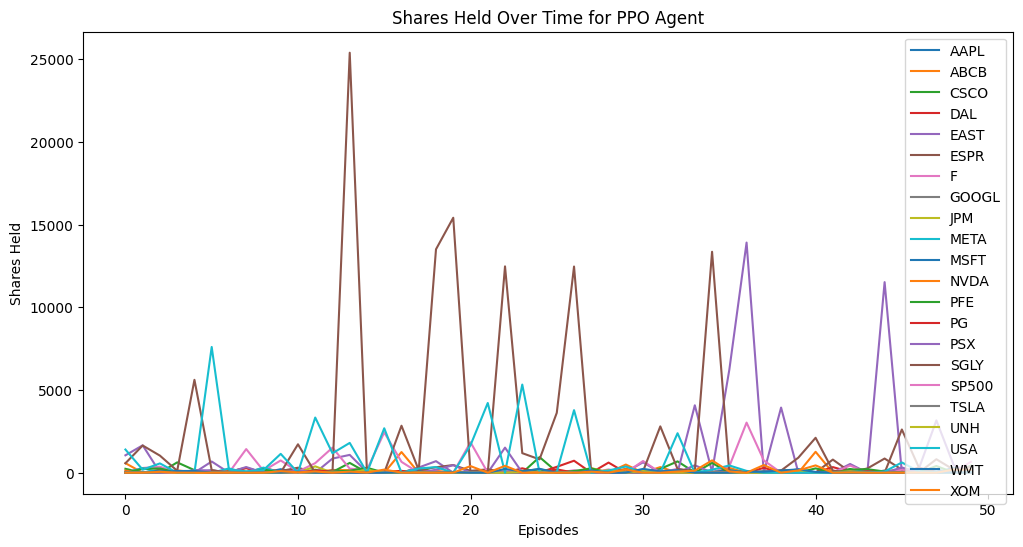

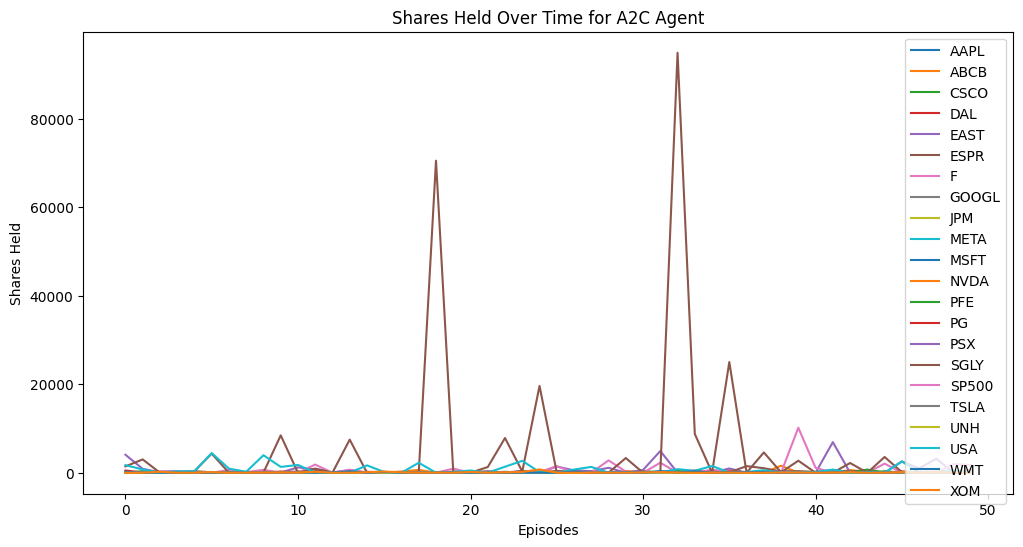

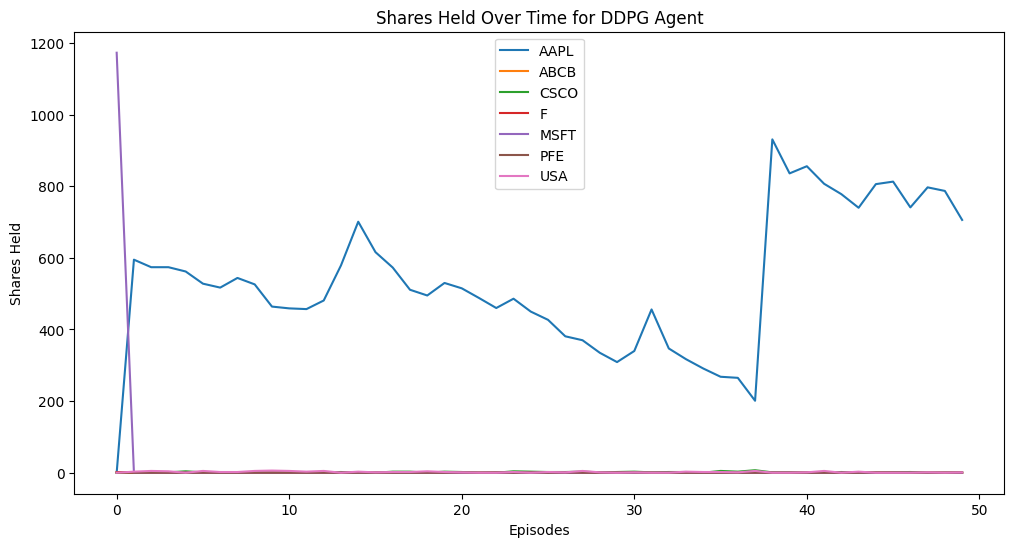

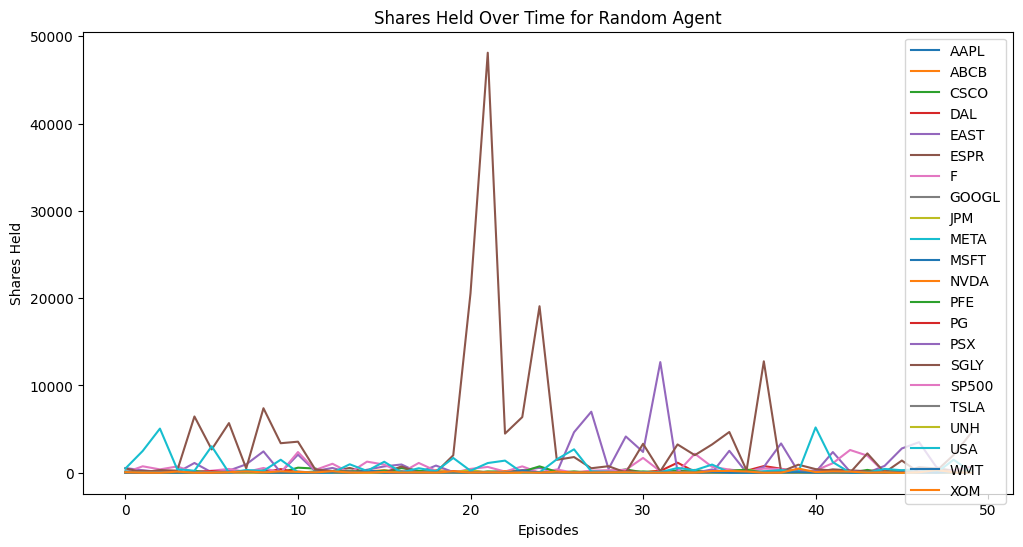

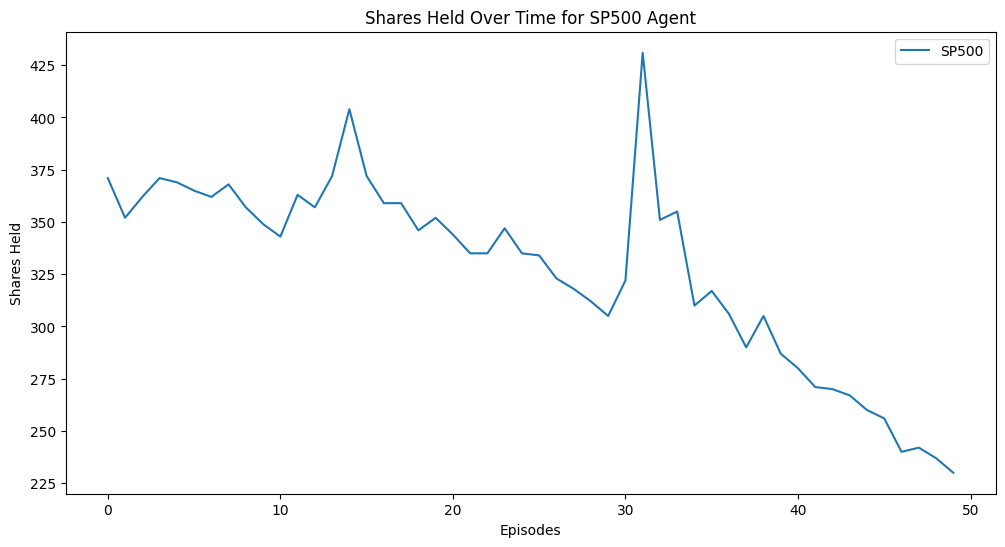

In [22]:
SharesHeldPlot(metrics_resume)

In [1]:
metrics_resume

NameError: name 'metrics_resume' is not defined

In [23]:
metrics_resume['PPO Agent']['stds']

[0.0008212052995025291,
 0.0004123759251103316,
 0.0010512944078666139,
 0.0014153305372824766,
 0.0010944547149869775,
 0.001216949142529632,
 0.000889561793396799,
 0.003611021799395012,
 0.000754810355540535,
 0.0013951753703842933,
 0.0008497961116283485,
 0.0017989115853953147,
 0.0011676739512461421,
 0.0018629133514121063,
 0.0006869327433064987,
 0.0031027090066974507,
 0.0006584069769982103,
 0.004141454313776068,
 0.0013197110094812976,
 0.0008879691524137543,
 0.0008298261700102077,
 0.0008712193896607169,
 0.0015342857824802783,
 0.0013472073034547108,
 0.001288547310919516,
 0.002689864059043525,
 0.0007839319353887332,
 0.0014114181524175309,
 0.002598480689380926,
 0.004152072490279039,
 0.003040447486910366,
 0.005734345168819323,
 0.0036476808335929103,
 0.003161098756831499,
 0.002679065457827897,
 0.004299598276302183,
 0.0012588211496812175,
 0.0015079508333808282,
 0.002115381260247806,
 0.0016647098403067286,
 0.001403199344994129,
 0.0008246754960947379,
 0.00215